In [7]:
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# Data
from dataloader import samlet_df
df = samlet_df.copy()

# Tilbage-beregning af “indkøb”

In [19]:
MONTH_MAP = {
    "jan":  1,
    "feb":  2,
    "mar":  3,
    "apr":  4,
    "maj":  5,
    "jun":  6,
    "jul":  7,
    "aug":  8,
    "sep":  9,
    "okt": 10,
    "nov": 11,
    "dec": 12,
}

MAANED_LABELS = ["Jan", "Feb", "Mar", "Apr", "Maj", "Jun",
                 "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]
 
def parse_maaned(maanedsnavn: str) -> int:
    tekst = str(maanedsnavn).lower()
    for key, num in MONTH_MAP.items():
        if key in tekst:
            return num
    raise ValueError(f"Ukendt månedsnavn: '{maanedsnavn}'")


# Beregn indkøbsmåned
KASSATIONS_AAR = 2023

df["kassations_maaned_nr"] = df["Måned"].apply(parse_maaned)
df["kassations_dato"] = pd.to_datetime({
    "year":  KASSATIONS_AAR,
    "month": df["kassations_maaned_nr"],
    "day":   15,        # 15. i måneden
})
 
df["indkoeb_dato"] = df["kassations_dato"] - pd.to_timedelta(
    df["Dage i cirkulation"].clip(lower=0), unit="D"
)
 
df["indkoeb_maaned"] = df["indkoeb_dato"].dt.to_period("M").dt.to_timestamp()
df["indkoeb_år"]     = df["indkoeb_dato"].dt.year
df["indkoeb_mdr_nr"] = df["indkoeb_dato"].dt.month

fordeling = (
    df.groupby(["indkoeb_år", "indkoeb_mdr_nr"])
    .size()
    .reset_index(name="antal")
)
 
pivot = (
    fordeling
    .pivot(index="indkoeb_år", columns="indkoeb_mdr_nr", values="antal")
    .reindex(columns=range(1, 13))   # sørg for alle 12 måneder er til stede
    .fillna(0)
    .astype(int)
)
pivot.columns = MAANED_LABELS
pivot.index.name = "År"
pivot["Total"] = pivot.sum(axis=1)

## Plot

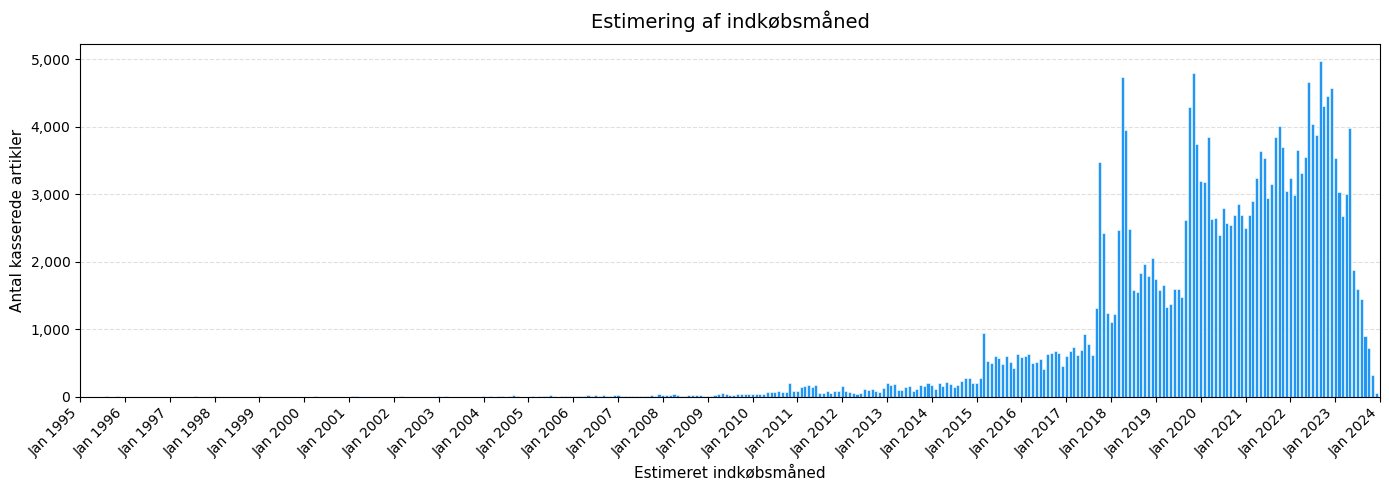

In [20]:
fordeling_plot = (
    df.groupby("indkoeb_maaned")
    .size()
    .reset_index(name="antal")
    .sort_values("indkoeb_maaned")
)
 
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(fordeling_plot["indkoeb_maaned"], fordeling_plot["antal"],
       width=25, color="#2196F3", edgecolor="white", linewidth=0.4)

ax.set_title("Estimering af indkøbsmåned",
             fontsize=14, pad=12)

ax.set_xlabel("Estimeret indkøbsmåned", fontsize=11)
ax.set_ylabel("Antal kasserede artikler", fontsize=11)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))

plt.xticks(rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlim(left=pd.Timestamp("1995-01-01"), right=pd.Timestamp("2024-01-01"))

plt.tight_layout()
plt.show()

### Beskåret

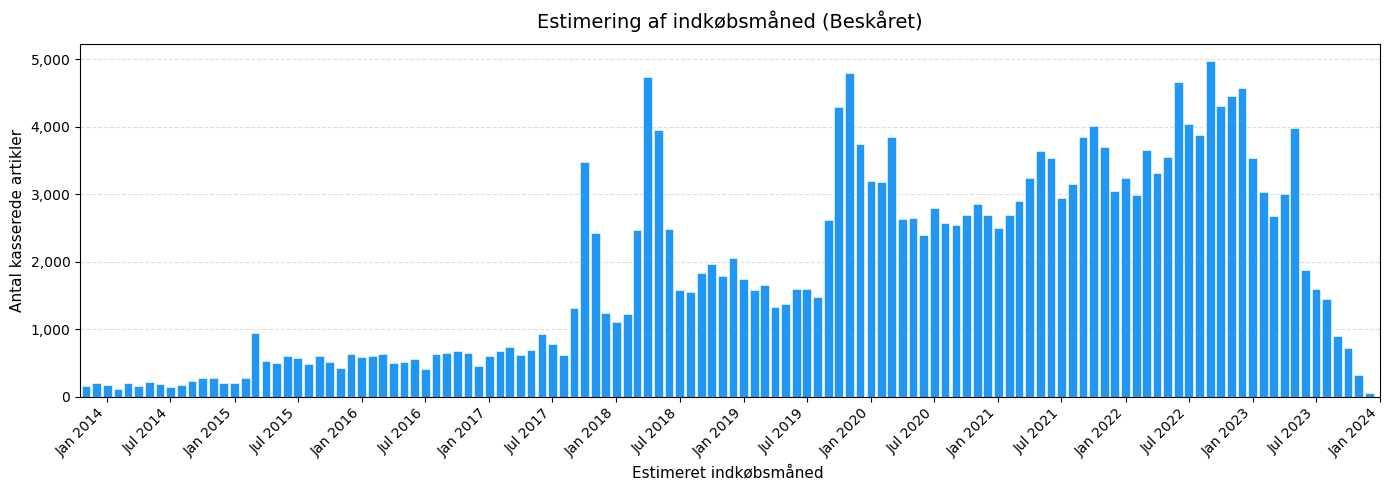

In [21]:
fordeling_plot = (
    df.groupby("indkoeb_maaned")
    .size()
    .reset_index(name="antal")
    .sort_values("indkoeb_maaned")
)
 
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(fordeling_plot["indkoeb_maaned"], fordeling_plot["antal"],
       width=25, color="#2196F3", edgecolor="white", linewidth=0.4)

ax.set_title("Estimering af indkøbsmåned (Beskåret)",
             fontsize=14, pad=12)

ax.set_xlabel("Estimeret indkøbsmåned ", fontsize=11)
ax.set_ylabel("Antal kasserede artikler", fontsize=11)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlim(left=pd.Timestamp("2013-10-15"), right=pd.Timestamp("2024-01-01"))
plt.tight_layout()

plt.show()

## Tabel

In [22]:
def style_pivot(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
 
    maaned_cols = MAANED_LABELS
    alle_værdier = df[maaned_cols].values.flatten()
    max_val = alle_værdier.max()
 
    for col in maaned_cols:
        for idx in df.index:
            v = df.loc[idx, col]
            if v == 0:
                styles.loc[idx, col] = "background-color: #f5f5f5; color: #bbb;"
            else:
                intensity = v / max_val
                grey = int(208 - intensity * (208 - 26))
                tekstfarve = "white" if intensity > 0.5 else "black"
                styles.loc[idx, col] = (
                    f"background-color: rgb({grey},{grey},{grey}); color: {tekstfarve};"
                )
 
    # Total-kolonne: fed + blå
    for idx in df.index:
        styles.loc[idx, "Total"] = "font-weight: bold; background-color: #e8f0fe;"
 
    return styles
 
display(
    pivot.style
    .apply(style_pivot, axis=None)
    .set_caption("Estimeret indkøbsmåned for kasseret tøj — antal pr. år og måned")
    .set_table_styles([
        {"selector": "caption",
         "props": "font-size: 14px; font-weight: bold; padding-bottom: 8px;"},
        {"selector": "th",
         "props": "background-color: #1a73e8; color: white; padding: 6px 10px; text-align: center;"},
        {"selector": "td",
         "props": "padding: 4px 10px; text-align: right;"},
    ])
    .format("{:,}"))

,Jan,Feb,Mar,Apr,Maj,Jun,Jul,Aug,Sep,Okt,Nov,Dec,Total
År,,,,,,,,,,,,,
1995,0,0,0,0,0,0,0,1,0,0,1,0,2
1997,0,0,0,0,0,0,0,3,0,0,0,0,3
1998,1,0,0,0,0,0,0,0,0,0,0,0,1
1999,1,0,0,0,0,0,0,0,0,0,0,0,1
2000,0,0,0,1,0,0,0,0,0,0,0,0,1
2001,0,1,1,0,0,0,0,0,0,0,0,0,2
2002,0,0,1,0,0,0,0,0,0,0,0,0,1
2003,2,0,1,0,0,0,0,0,0,0,0,0,3
2004,4,0,9,0,2,1,0,4,18,1,0,0,39
